# Sentiment Analysis

requires virtual environment nlp (3.11.14)

### imports

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
#expanding column width
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_pickle('/Users/isishassan/Documents/Ironhack/FinalProject/df.pkl')

In [5]:
#sign map
sign_map = {
    "aries": 1,
    "taurus": 2,
    "gemini": 3,
    "cancer": 4,
    "leo": 5,
    "virgo": 6,
    "libra": 7,
    "scorpio": 8,
    "sagittarius": 9,
    "capricorn": 10,
    "aquarius": 11,
    "pisces": 12
}

In [ ]:
#dates 1
#making sure it's the right format
df["date"] = pd.to_datetime(df["date"])

#creating date columns
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["weeknumber"] = df["date"].dt.isocalendar().week
df["weekday"] = (df["date"].dt.weekday < 5).astype(int)   # Mon–Fri = 1
df["weekend"] = (df["date"].dt.weekday >= 5).astype(int)  # Sat/Sun = 1

In [114]:
#element map

#elements
element_map = {
    "aries": "Fire",
    "leo": "Fire",
    "sagittarius": "Fire",
    
    "taurus": "Earth",
    "virgo": "Earth",
    "capricorn": "Earth",
    
    "gemini": "Air",
    "libra": "Air",
    "aquarius": "Air",
    
    "cancer": "Water",
    "scorpio": "Water",
    "pisces": "Water"
}

element_colors = {
    "Fire": "red",
    "Earth": "green",
    "Air": "lightblue",
    "Water": "blue"
}

In [ ]:
#adding 'season'

zodiac_ranges = {
    1: ((3,21),(4,19)),   # Aries
    2: ((4,20),(5,20)),   # Taurus
    3: ((5,21),(6,20)),   # Gemini
    4: ((6,21),(7,22)),   # Cancer
    5: ((7,23),(8,22)),   # Leo
    6: ((8,23),(9,22)),   # Virgo
    7: ((9,23),(10,22)),  # Libra
    8: ((10,23),(11,21)), # Scorpio
    9: ((11,22),(12,21)), # Sagittarius
    10: ((12,22),(1,19)), # Capricorn
    11: ((1,20),(2,18)),  # Aquarius
    12: ((2,19),(3,20))   # Pisces
}

def is_in_season(date, sign_id):

    month = date.month
    day = date.day
    
    start, end = zodiac_ranges[sign_id]

    start_m, start_d = start
    end_m, end_d = end

    # handle ranges crossing year boundary (Capricorn)
    if start_m > end_m:
        return (
            (month > start_m or month < end_m) or
            (month == start_m and day >= start_d) or
            (month == end_m and day <= end_d)
        )
    else:
        return (
            (month > start_m and month < end_m) or
            (month == start_m and day >= start_d) or
            (month == end_m and day <= end_d)
        )

df["season"] = df.apply(
    lambda row: int(is_in_season(row["date"], row["sign_id"])),
    axis=1
)

## Sentiment analyis

In [ ]:
pip install transformers torch

In [17]:
#load model
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=-1   # ensures CPU usage on Mac
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 21308.10it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#convert to string
texts = df["horoscope"].astype(str).tolist()

#run sentiment 
results = sentiment_pipeline(
    texts,
    batch_size=32,
    truncation=True,
    max_length=512                  #horoscopes above 512 tokens get cut off
)


In [ ]:
#get predictions
df["sentiment_label"] = [r["label"] for r in results]
df["sentiment_conf"]  = [r["score"] for r in results]

this took 34 mins with batch size = 32

In [37]:
print(results[:3])

[{'label': 'positive', 'score': 0.8948191404342651}, {'label': 'neutral', 'score': 0.5868271589279175}, {'label': 'neutral', 'score': 0.5765708684921265}]


### Analysis

In [38]:
df.groupby("sign")["sentiment_label"].value_counts(normalize=True)

sign         sentiment_label
aquarius     positive           0.496046
             neutral            0.389648
             negative           0.114306
aries        positive           0.501437
             neutral            0.369971
             negative           0.128592
cancer       positive           0.517588
             neutral            0.380474
             negative           0.101938
capricorn    positive           0.518359
             neutral            0.362851
             negative           0.118790
gemini       positive           0.466236
             neutral            0.416667
             negative           0.117098
leo          positive           0.501795
             neutral            0.377602
             negative           0.120603
libra        positive           0.511494
             neutral            0.377155
             negative           0.111351
pisces       positive           0.513281
             neutral            0.370424
             negative       

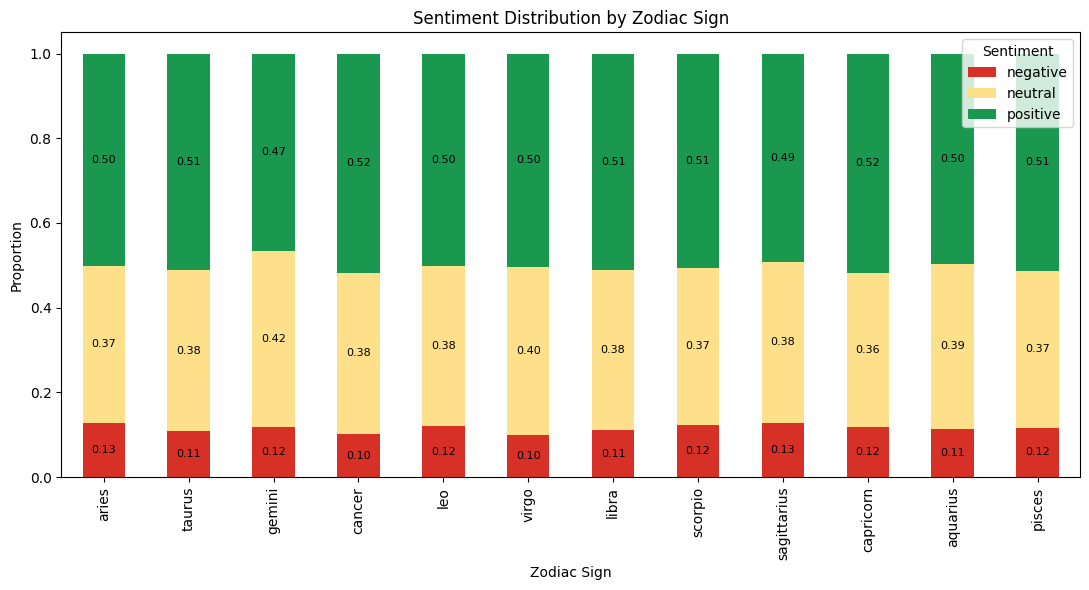

In [81]:
# create sentiment table
sentiment_table = (
    df.groupby("sign")["sentiment_label"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

# ensure sentiment order
sentiment_table = sentiment_table[["negative","neutral","positive"]]

# add zodiac order
sentiment_table["order"] = sentiment_table.index.map(sign_map)

# sort by zodiac cycle
sentiment_table = sentiment_table.sort_values("order")

# remove helper column
sentiment_table = sentiment_table.drop(columns="order")

# plot
colors = ["#d73027","#fee08b","#1a9850"]


ax = sentiment_table.plot(
    kind="bar",
    stacked=True,
    figsize=(11,6),
    color=colors
)

# annotate values
for container in ax.containers:
    labels = [f"{v:.2f}" if v > 0.02 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8)

plt.title("Sentiment Distribution by Zodiac Sign")
plt.xlabel("Zodiac Sign")
plt.ylabel("Proportion")
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()
plt.show()

In [39]:
sentiment_numeric = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

df["sentiment_score"] = df["sentiment_label"].map(sentiment_numeric)

In [40]:
df.groupby("sign")["sentiment_score"].mean()

sign
aquarius       0.381740
aries          0.372845
cancer         0.415650
capricorn      0.399568
gemini         0.349138
leo            0.381192
libra          0.400144
pisces         0.396985
sagittarius    0.362851
scorpio        0.383178
taurus         0.403874
virgo          0.404454
Name: sentiment_score, dtype: float64

### Heatmap

In [ ]:
!pip install seaborn
import seaborn as sns

In [72]:
heatmap_data = df.pivot_table(
    values="sentiment_score",
    index="sign",
    columns="season",
    aggfunc="mean"
)

In [73]:
heatmap_data["order"] = heatmap_data.index.map(sign_map)
heatmap_data = heatmap_data.sort_values("order")
heatmap_data = heatmap_data.drop(columns="order")

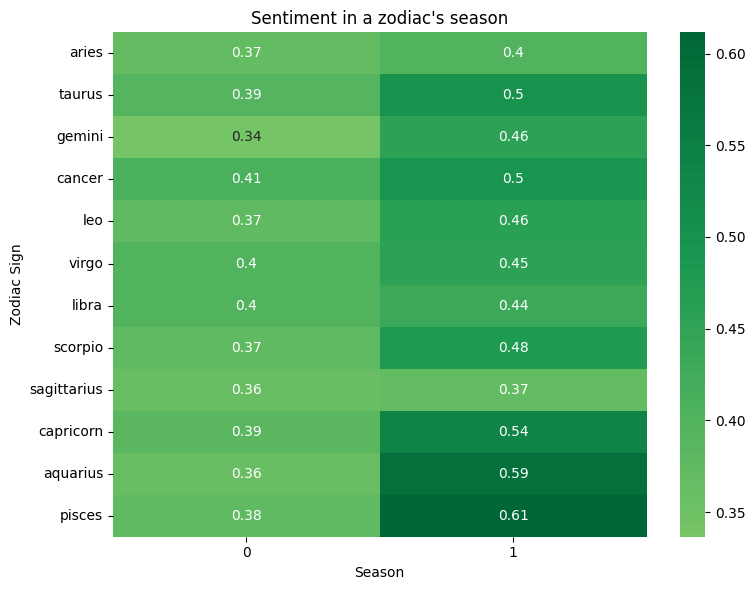

In [76]:
plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    center=0,
    annot=True
)

plt.title("Sentiment in a zodiac's season")
plt.xlabel("Season")
plt.ylabel("Zodiac Sign")
# Customize the legend
#plt.legend(title= "Is it your birthday season?", loc= "upper left",labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

In [68]:
heatmap_data = df.pivot_table(
    values="sentiment_score",
    index="sign",
    columns="month",
    aggfunc="mean"
)

#sorting it
heatmap_data["order"] = heatmap_data.index.map(sign_map)
heatmap_data = heatmap_data.sort_values("order")
heatmap_data = heatmap_data.drop(columns="order")

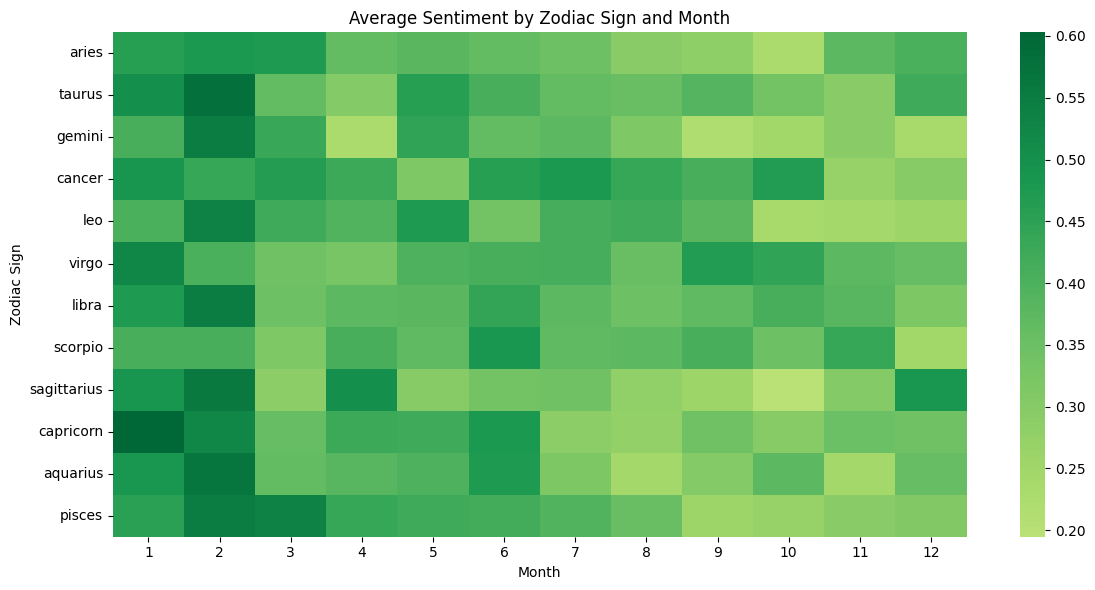

In [69]:
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    center=0,
    annot=False
)

plt.title("Average Sentiment by Zodiac Sign and Month")
plt.xlabel("Month")
plt.ylabel("Zodiac Sign")

plt.tight_layout()
plt.show()

## Transformers: Themes

https://huggingface.co/MoritzLaurer/ModernBERT-large-zeroshot-v2.0 

In [94]:
#getting my zero shot classifier model

from transformers import pipeline

theme_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-xsmall-zeroshot-v1.1-all-33",
    device=-1
)

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 4518.62it/s]


In [ ]:
#themes to evaluate

themes = [
    "action and initiative",
    "emotions and feelings",
    "freedom and self-expression",
    "career and work"
]

In [ ]:
texts = [t[:800] for t in df["horoscope"].astype(str)]          #shortening my text to first 800 chars for speed


results = theme_classifier(
    texts,                       
    candidate_labels=themes,
    batch_size=32,
    truncation=True,
    max_length=512
)

In [102]:
#top theme per sign

df["theme"] = [r["labels"][0] for r in results]
df["theme_conf"] = [r["scores"][0] for r in results]

In [ ]:
#df["theme"]

In [104]:
df.groupby("sign")["theme"].value_counts(normalize=True)

sign         theme                      
aquarius     action and initiative          0.398275
             emotions and feelings          0.350108
             career and work                0.167505
             freedom and self-expression    0.084112
aries        action and initiative          0.398707
             emotions and feelings          0.337644
             career and work                0.176724
             freedom and self-expression    0.086925
cancer       action and initiative          0.382627
             emotions and feelings          0.353912
             career and work                0.173008
             freedom and self-expression    0.090452
capricorn    action and initiative          0.382289
             emotions and feelings          0.333333
             career and work                0.204464
             freedom and self-expression    0.079914
gemini       action and initiative          0.413075
             emotions and feelings          0.311782
     

## Sentence Embeddings: Themes

In [115]:
#adding element to my dataframe
df["element"] = df["sign"].map(element_map)

In [ ]:
pip install sentence-transformers

In [106]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11189.74it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
themes = {
"fire_style": "action, confidence, leadership, bold decisions",
"water_style": "emotions, intuition, sensitivity",
"earth_style": "practical thinking, stability, work and responsibility",
"air_style": "communication, ideas, intellectual thinking"
}

In [ ]:
themes_2 = {
"fire_style": "passionate, action, energy",
"earth_style": "loyal, stability, sensual",
"water_style": "emotion,sensitivity,intuition",
"air_style": "communication,adaptable,curious"
}

In [155]:
themes_3 = {
"fire_style": "bold, confidence, energy",
"earth_style": "grounded, reliable, sensual",
"water_style": "emotion,nurturing,empathy",
"air_style": "communication,idea,social"
}

#### theme embeddings

In [164]:
#themes
theme_names = list(themes.keys())
theme_descriptions = list(themes.values())

theme_embeddings = model.encode(theme_descriptions)

In [165]:
#themes_2
theme_names = list(themes_2.keys())
theme_descriptions_2 = list(themes_2.values())

theme_embeddings_2 = model.encode(theme_descriptions_2)

In [166]:
#themes_3

theme_names = list(themes_3.keys())
theme_descriptions_3 = list(themes_3.values())

theme_embeddings_3 = model.encode(theme_descriptions_3)

#### text embeddings

In [157]:
#embeddings

texts = [t[:1000] for t in df["horoscope"].astype(str)]

text_embeddings = model.encode(
    texts,
    batch_size=64,          
    show_progress_bar=True
)

Batches: 100%|██████████| 261/261 [03:09<00:00,  1.38it/s]


#### cosine similarity

In [167]:
#theme
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(text_embeddings, theme_embeddings)

In [168]:
#theme_2

from sklearn.metrics.pairwise import cosine_similarity

similarities_2 = cosine_similarity(text_embeddings, theme_embeddings_2)

In [169]:
#theme_3

from sklearn.metrics.pairwise import cosine_similarity

similarities_3 = cosine_similarity(text_embeddings, theme_embeddings_3)

#### best theme

In [170]:
#theme
best_theme_index = np.argmax(similarities, axis=1)

df["theme_1"] = [theme_names[i] for i in best_theme_index]

#theme_2
best_theme_index_2 = np.argmax(similarities_2, axis=1)

df["theme_2"] = [theme_names[i] for i in best_theme_index_2]

#theme_3
best_theme_index_3 = np.argmax(similarities_3, axis=1)

df["theme_3"] = [theme_names[i] for i in best_theme_index_3]


In [171]:
df.groupby("sign")["theme_1"].value_counts(normalize=True)

sign         theme_1    
aquarius     water_style    0.445723
             earth_style    0.260244
             air_style      0.227894
             fire_style     0.066139
aries        water_style    0.441092
             earth_style    0.252155
             air_style      0.219109
             fire_style     0.087644
cancer       water_style    0.455133
             earth_style    0.253410
             air_style      0.221106
             fire_style     0.070352
capricorn    water_style    0.426926
             air_style      0.254140
             earth_style    0.236141
             fire_style     0.082793
gemini       water_style    0.444684
             air_style      0.250718
             earth_style    0.232759
             fire_style     0.071839
leo          water_style    0.462312
             earth_style    0.246231
             air_style      0.209620
             fire_style     0.081838
libra        water_style    0.455460
             earth_style    0.245690
             

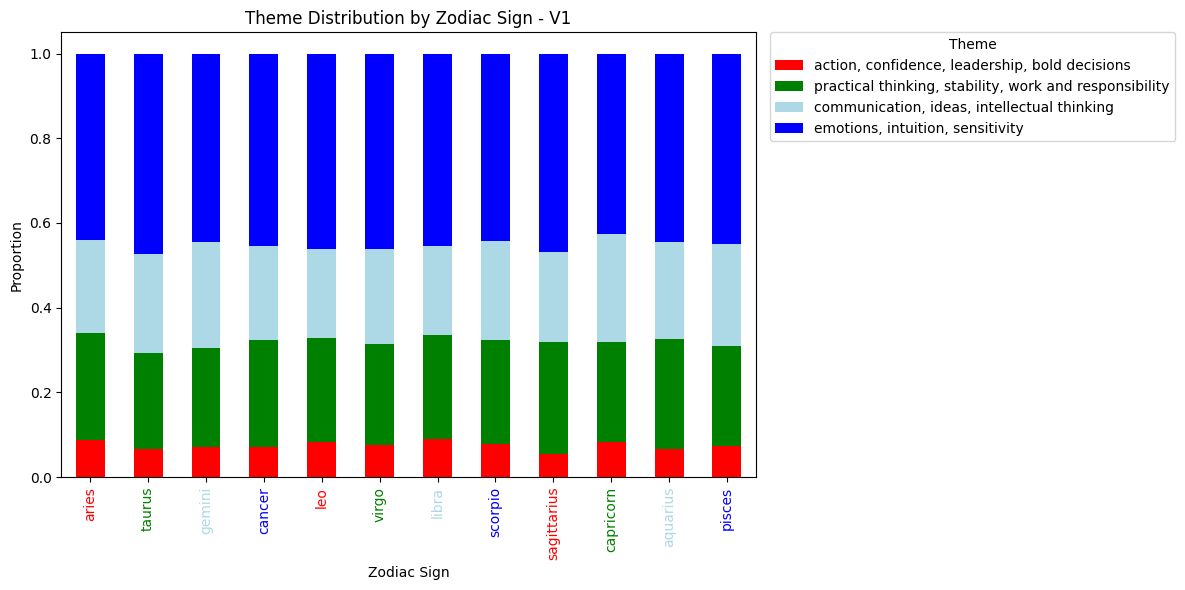

In [175]:
# create theme table
theme_table = (
    df.groupby("sign")["theme_1"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

# ensure theme order
theme_table = theme_table[["fire_style","earth_style","air_style","water_style"]]

# add zodiac order
theme_table["order"] = theme_table.index.map(sign_map)
theme_table = theme_table.sort_values("order")
theme_table = theme_table.drop(columns="order")


# theme colors (bars)
theme_colors = {
    "fire_style": element_colors["Fire"],
    "earth_style": element_colors["Earth"],
    "air_style": element_colors["Air"],
    "water_style": element_colors["Water"]
}

bar_colors = [theme_colors[c] for c in theme_table.columns]


# plot
ax = theme_table.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=bar_colors
)

# color x-axis labels by element
for label in ax.get_xticklabels():
    sign = label.get_text()
    element = element_map.get(sign)
    label.set_color(element_colors[element])


# legend labels using theme descriptions
legend_labels = [themes[c] for c in theme_table.columns]

ax.legend(
    legend_labels,
    title="Theme",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)


plt.title("Theme Distribution by Zodiac Sign - V1")
plt.xlabel("Zodiac Sign")
plt.ylabel("Proportion")

plt.tight_layout()
plt.show()

<Axes: xlabel='element'>

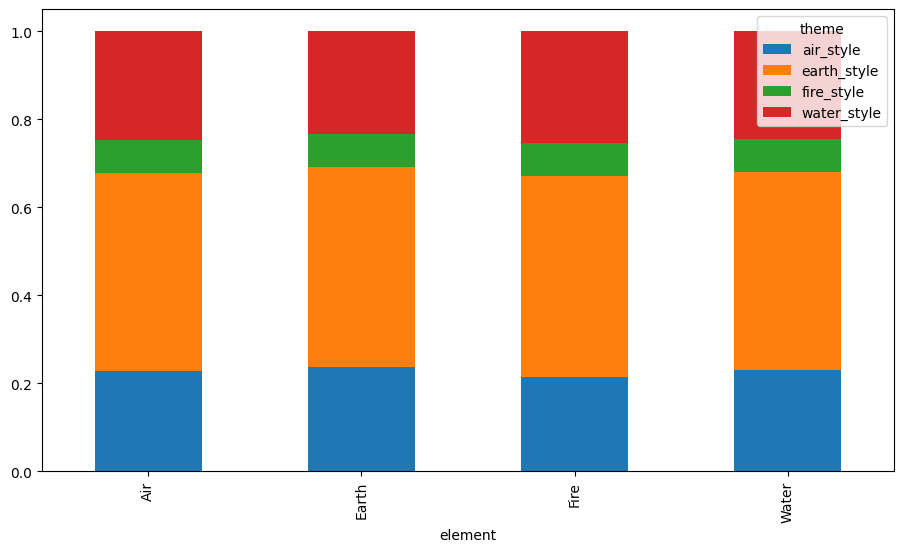

In [128]:
theme_table = (
    df.groupby("element")["theme"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

theme_table.plot(
    kind="bar",
    stacked=True,
    figsize=(11,6)
)

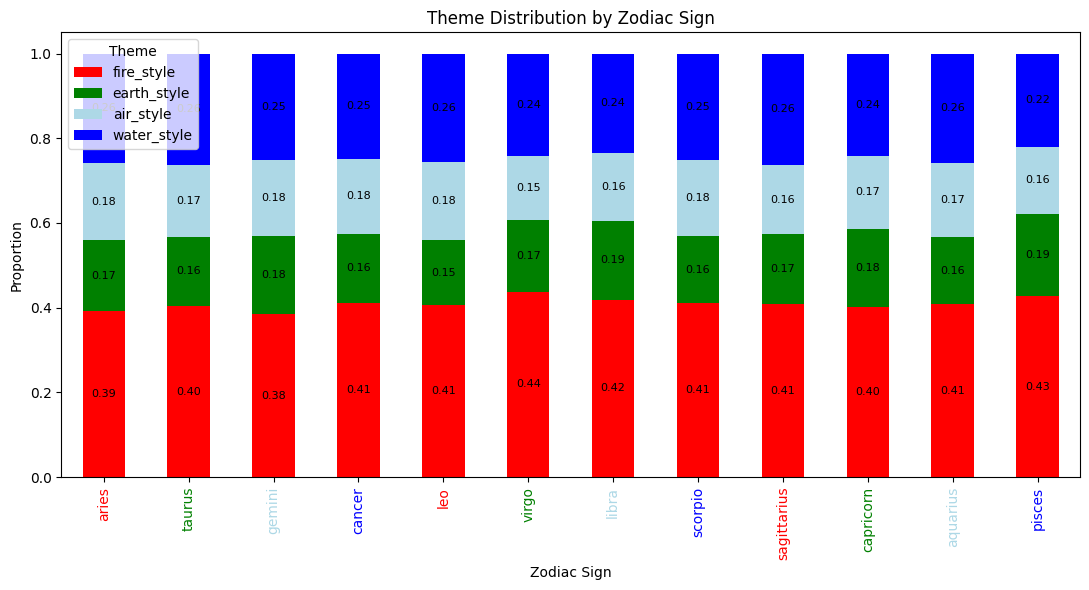

In [137]:
#theme 2
# create theme table
theme_table = (
    df.groupby("sign")["theme"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

# ensure theme order
theme_table = theme_table[["fire_style","earth_style","air_style","water_style"]]

# add zodiac order
theme_table["order"] = theme_table.index.map(sign_map)
theme_table = theme_table.sort_values("order")
theme_table = theme_table.drop(columns="order")


# theme colors (bars)
theme_colors = {
    "fire_style": element_colors["Fire"],
    "earth_style": element_colors["Earth"],
    "air_style": element_colors["Air"],
    "water_style": element_colors["Water"]
}

bar_colors = [theme_colors[c] for c in theme_table.columns]


# plot
ax = theme_table.plot(
    kind="bar",
    stacked=True,
    figsize=(11,6),
    color=bar_colors
)


# add values inside bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center", fontsize=8)


# color x-axis labels by element
for label in ax.get_xticklabels():
    sign = label.get_text()
    element = element_map.get(sign)
    label.set_color(element_colors[element])


plt.title("Theme Distribution by Zodiac Sign")
plt.xlabel("Zodiac Sign")
plt.ylabel("Proportion")
plt.legend(title="Theme")

plt.tight_layout()
plt.show()

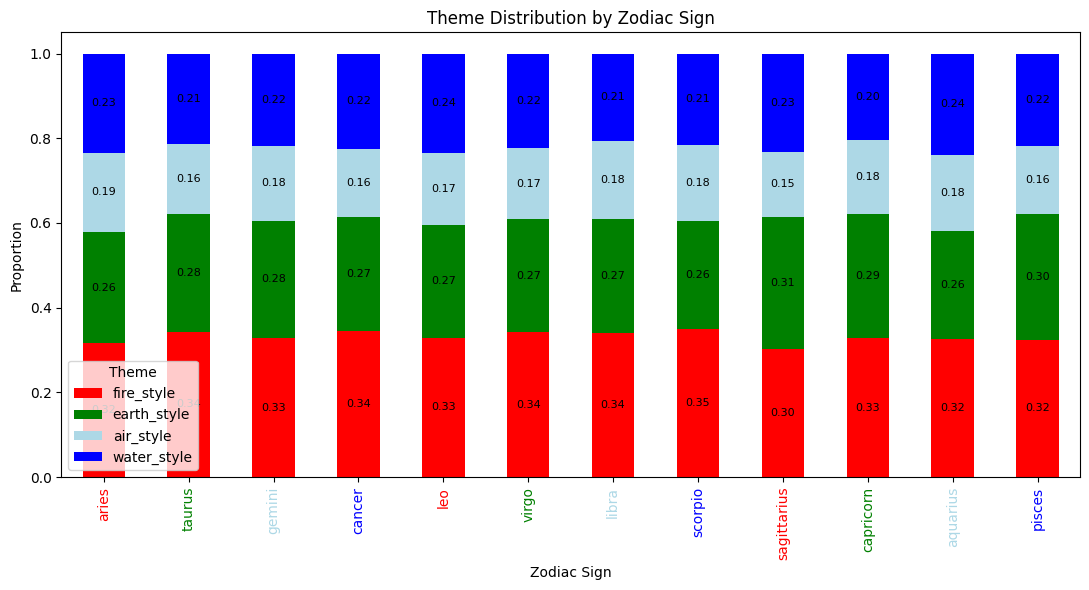

In [154]:
# create theme table
theme_table = (
    df.groupby("sign")["theme"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

# ensure theme order
theme_table = theme_table[["fire_style","earth_style","air_style","water_style"]]

# add zodiac order
theme_table["order"] = theme_table.index.map(sign_map)
theme_table = theme_table.sort_values("order")
theme_table = theme_table.drop(columns="order")


# theme colors (bars)
theme_colors = {
    "fire_style": element_colors["Fire"],
    "earth_style": element_colors["Earth"],
    "air_style": element_colors["Air"],
    "water_style": element_colors["Water"]
}

bar_colors = [theme_colors[c] for c in theme_table.columns]


# plot
ax = theme_table.plot(
    kind="bar",
    stacked=True,
    figsize=(11,6),
    color=bar_colors
)


# add values inside bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="center", fontsize=8)


# color x-axis labels by element
for label in ax.get_xticklabels():
    sign = label.get_text()
    element = element_map.get(sign)
    label.set_color(element_colors[element])


plt.title("Theme Distribution by Zodiac Sign")
plt.xlabel("Zodiac Sign")
plt.ylabel("Proportion")
plt.legend(title="Theme")

plt.tight_layout()
plt.show()

In [176]:
## all three
def build_theme_table(df, theme_column):
    
    theme_table = (
        df.groupby("sign")[theme_column]
          .value_counts(normalize=True)
          .unstack()
          .fillna(0)
    )

    # ensure consistent order
    theme_table = theme_table[["fire_style","earth_style","air_style","water_style"]]

    # zodiac order
    theme_table["order"] = theme_table.index.map(sign_map)
    theme_table = theme_table.sort_values("order")
    theme_table = theme_table.drop(columns="order")

    return theme_table

theme_table_1 = build_theme_table(df, "theme_1")
theme_table_2 = build_theme_table(df, "theme_2")
theme_table_3 = build_theme_table(df, "theme_3")

theme_colors = {
    "fire_style": element_colors["Fire"],
    "earth_style": element_colors["Earth"],
    "air_style": element_colors["Air"],
    "water_style": element_colors["Water"]
}

bar_colors = [theme_colors[c] for c in theme_table_1.columns]

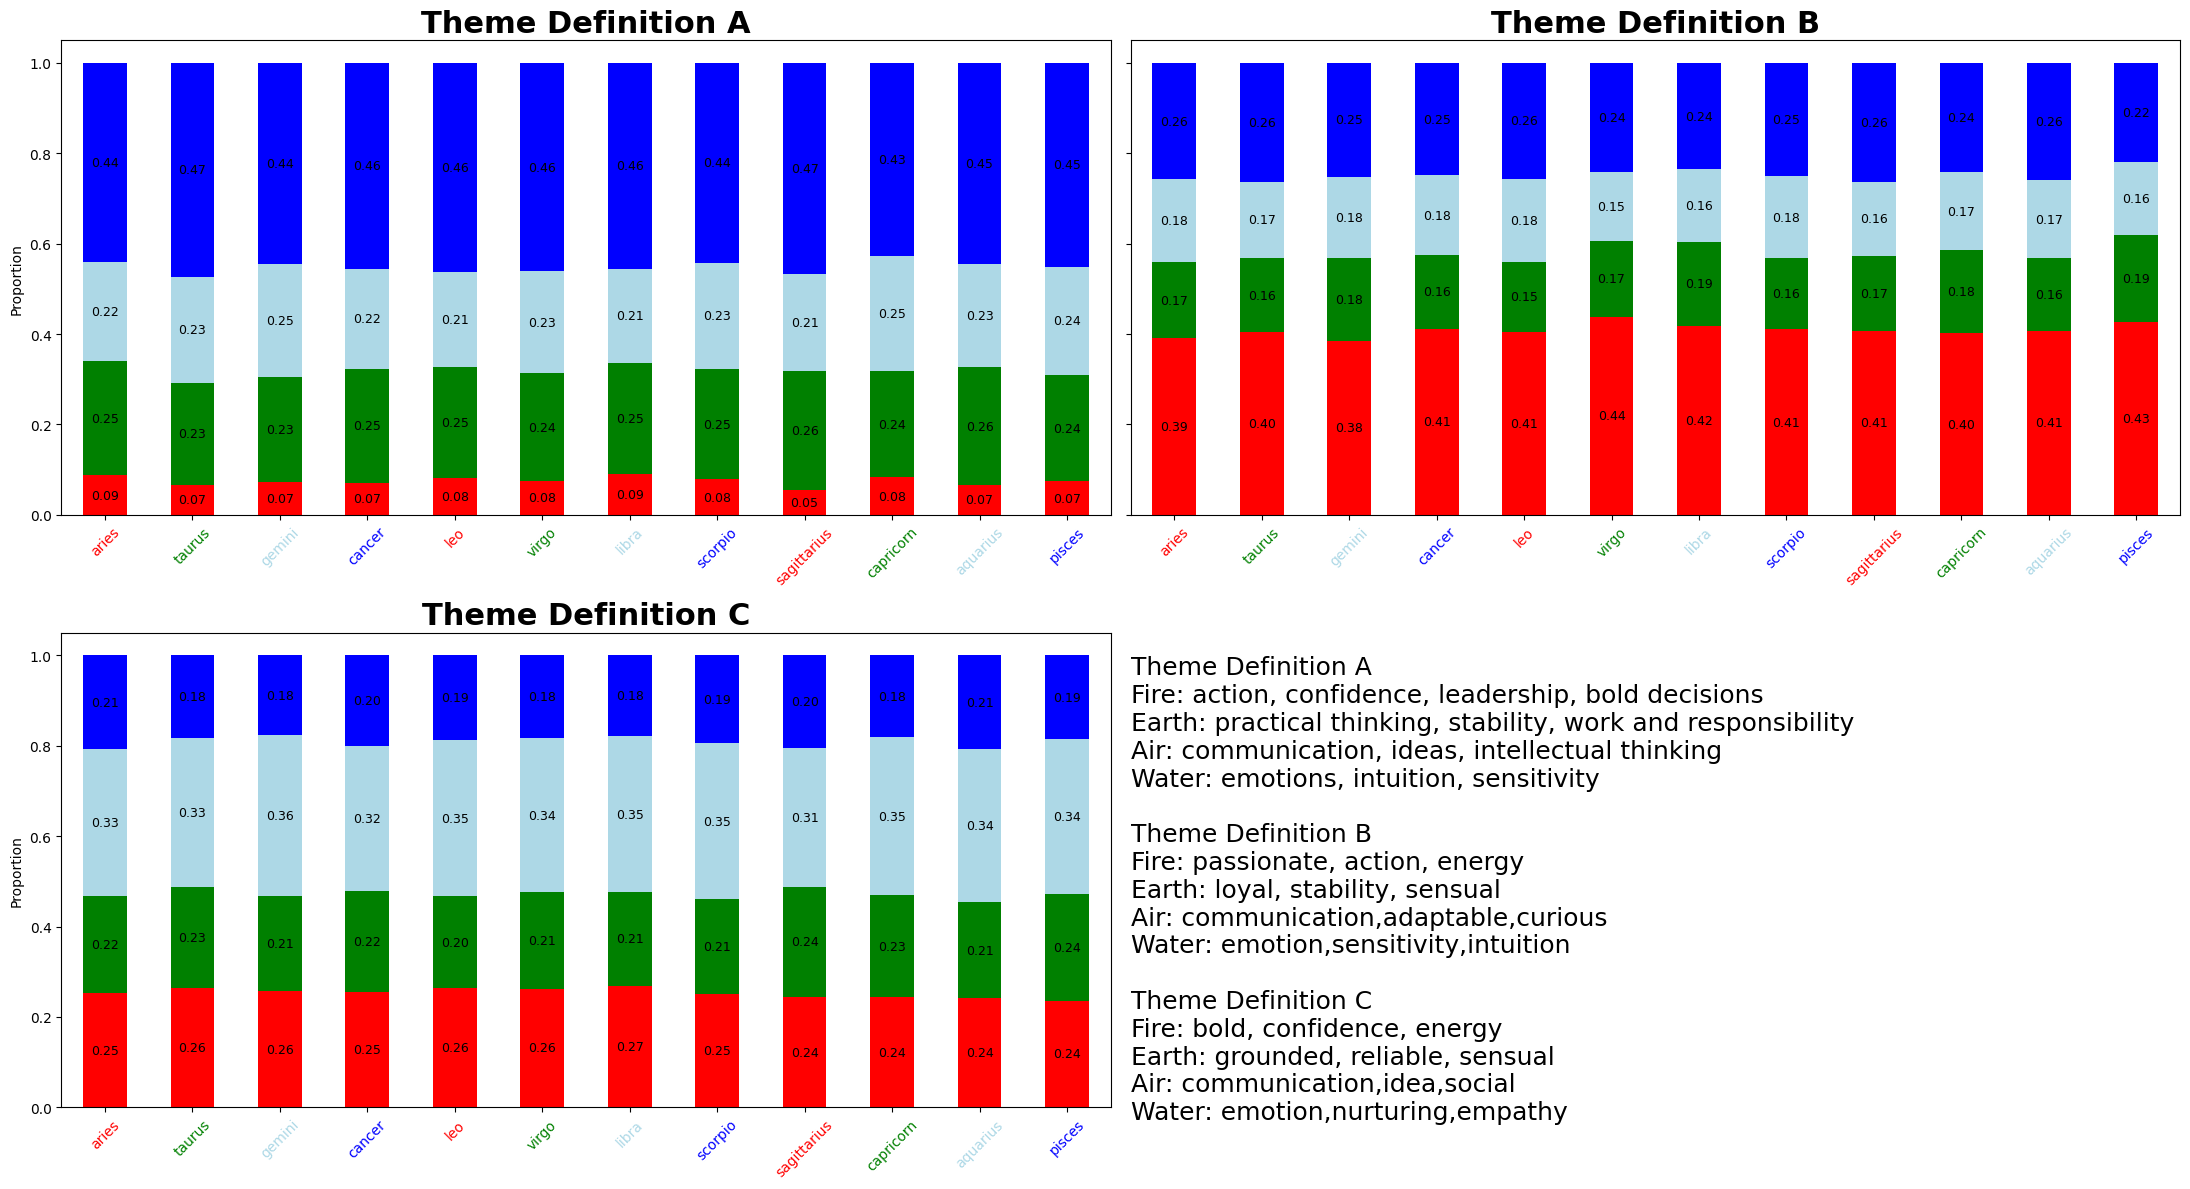

In [190]:
fig, axes = plt.subplots(2, 2, figsize=(22,12), sharey=True)

tables = [theme_table_1, theme_table_2, theme_table_3]
titles = ["Theme Definition A", "Theme Definition B", "Theme Definition C"]

# positions of the 3 charts
chart_axes = [axes[0,0], axes[0,1], axes[1,0]]

for ax, table, title in zip(chart_axes, tables, titles):

    table.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=bar_colors,
        legend=False
    )

    # color sign labels
    for label in ax.get_xticklabels():
        sign = label.get_text()
        element = element_map.get(sign)
        label.set_color(element_colors[element])

    # add bar values
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="center", fontsize=9)

    ax.set_title(title,fontsize=22,fontweight="bold")
    ax.set_xlabel("",fontsize=18,fontweight="bold")         #somehow does not impact fontsize
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel("Proportion")


# ── Bottom-right quadrant: theme definitions text ──

axes[1,1].axis("off")

text = (
    "Theme Definition A\n"
    f"Fire: {themes['fire_style']}\n"
    f"Earth: {themes['earth_style']}\n"
    f"Air: {themes['air_style']}\n"
    f"Water: {themes['water_style']}\n\n"

    "Theme Definition B\n"
    f"Fire: {themes_2['fire_style']}\n"
    f"Earth: {themes_2['earth_style']}\n"
    f"Air: {themes_2['air_style']}\n"
    f"Water: {themes_2['water_style']}\n\n"

    "Theme Definition C\n"
    f"Fire: {themes_3['fire_style']}\n"
    f"Earth: {themes_3['earth_style']}\n"
    f"Air: {themes_3['air_style']}\n"
    f"Water: {themes_3['water_style']}"
)

axes[1,1].text(
    0,
    1,
    text,
    fontsize=18,
    va="top"
)


plt.tight_layout()
plt.show()

In [192]:
#storing updated df in pickle, to pull for text generation

df.to_pickle('df_for_text_gen.pkl')